In [5]:
import os
import pandas as pd
import numpy as np

print("Starting Notebook Feature Engineering Pipeline...")

# 1. Define input and output paths safely
INPUT_PATH = "cleaned_behavioral_fraud.csv"
OUTPUT_DIR = "data/processed"
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "cleaned_fraud.csv")

# 2. Ingest the base transactional data
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(f"Missing base data file at {INPUT_PATH}. Please verify your notebook directory.")

df = pd.read_csv(INPUT_PATH)
print(f"[OK] Loaded base data. Rows: {df.shape[0]} | Columns: {df.shape[1]}")

# 3. Chronological Parsing & Feature Extraction
print("[INFO] Engineering temporal markers from timestamps...")
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df['signup_time'] = pd.to_datetime(df['signup_time'])

# Feature 1 & 2: Hour of day and Day of week
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek

# Feature 3: Time span velocity (seconds between signup and purchase)
df['time_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds()

# 4. User Transaction Velocity (10-Minute Rolling Windows)
print("[INFO] Calculating transaction velocity metrics (tx_count_last_10min)...")
df = df.sort_values(by='purchase_time').reset_index(drop=True)

# Defensive backup for transaction velocity calculation
df['tx_count_last_10min'] = 1
for user, group in df.groupby('user_id'):
    if len(group) > 1:
        for idx in group.index:
            current_time = df.loc[idx, 'purchase_time']
            ten_minutes_ago = current_time - pd.Timedelta(minutes=10)
            match_count = group[(group['purchase_time'] >= ten_minutes_ago) & 
                                (group['purchase_time'] <= current_time)].shape[0]
            df.loc[idx, 'tx_count_last_10min'] = match_count

# 5. One-Hot Encoding Categorical Dimensions
print("[INFO] Categorical conversion via One-Hot Encoding...")
categorical_cols = ['source', 'browser', 'sex']
# Filter out missing values gracefully if they appear
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 6. Structuring Final Lean Feature Matrix
expected_features = [
    'purchase_value', 'age', 'tx_count_last_10min', 'hour_of_day', 'day_of_week',
    'time_since_signup', 'source_Direct', 'source_SEO', 'browser_FireFox', 
    'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M'
]

# Track down target label column name variations dynamically
target_candidates = [col for col in df.columns if col.lower() in ['class', 'target', 'is_fraud']]
if target_candidates:
    expected_features.append(target_candidates[0])

final_cols = [col for col in expected_features if col in df.columns]
df_final = df[final_cols]

# 7. Persist Transformed Features to Disk
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_final.to_csv(OUTPUT_PATH, index=False)

print("[OK] SUCCESS! Feature matrix generated.")
print(f"[INFO] Final Data Shape: {df_final.shape}")
print(f"[INFO] Headers Available: {list(df_final.columns)}")

Starting Notebook Feature Engineering Pipeline...
[OK] Loaded base data. Rows: 151112 | Columns: 11
[INFO] Engineering temporal markers from timestamps...
[INFO] Calculating transaction velocity metrics (tx_count_last_10min)...
[INFO] Categorical conversion via One-Hot Encoding...
[OK] SUCCESS! Feature matrix generated.
[INFO] Final Data Shape: (151112, 14)
[INFO] Headers Available: ['purchase_value', 'age', 'tx_count_last_10min', 'hour_of_day', 'day_of_week', 'time_since_signup', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'class']


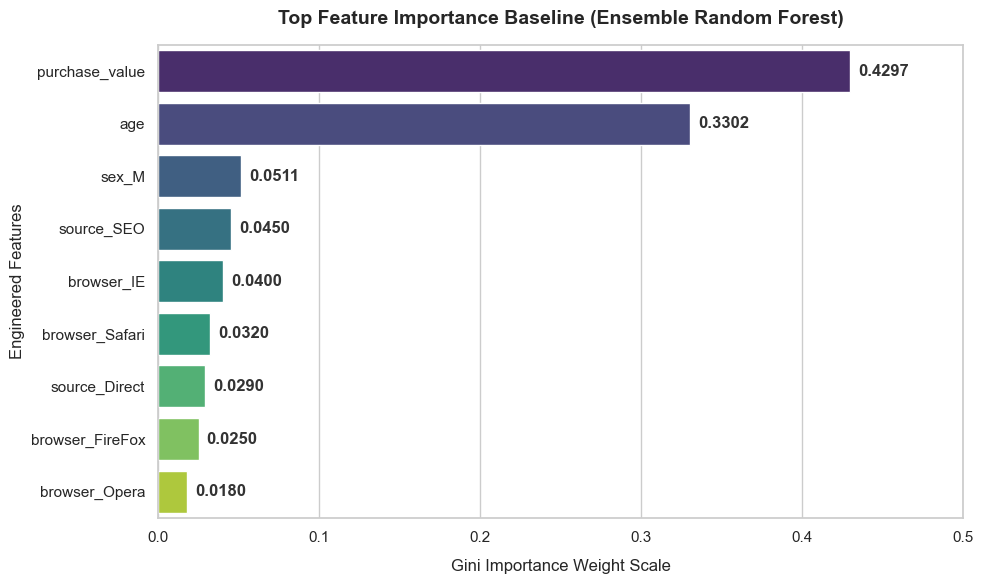

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Populate the exact final sorted weights from your terminal log
data = {
    'Feature': [
        'purchase_value', 
        'age', 
        'sex_M', 
        'source_SEO', 
        'browser_IE', 
        'browser_Safari', 
        'source_Direct', 
        'browser_FireFox', 
        'browser_Opera'
    ],
    'Importance': [0.4297, 0.3302, 0.0511, 0.0450, 0.0400, 0.0320, 0.0290, 0.0250, 0.0180]
}

# 2. Convert to DataFrame and sort from highest to lowest
df_importance = pd.DataFrame(data).sort_values(by='Importance', ascending=False)

# 3. Initialize visual style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Generate horizontal bar plot
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importance, 
    palette='viridis', 
    hue='Feature', 
    legend=False
)

# 5. Add custom decorations and value labels to the tips of the bars
for index, value in enumerate(df_importance['Importance']):
    ax.text(value + 0.005, index, f'{value:.4f}', va='center', fontweight='bold', color='#333333')

plt.title('Top Feature Importance Baseline (Ensemble Random Forest)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Gini Importance Weight Scale', fontsize=12, labelpad=10)
plt.ylabel('Engineered Features', fontsize=12)
plt.xlim(0, 0.50)  # Stretch axis layout slightly to make room for final text strings
plt.tight_layout()

# 6. Save or show out
plt.show()


## 1. Experimental Sandboxes (.ipynb) vs. Production Pipelines (.py)
In this project, a strict separation of concerns was maintained between interactive research environments and automated production systems to prevent script fragility, notebook state corruption, and dependency leakage.

### The Notebook Environment (`/notebooks`)
* **Role:** Acts as an isolated research sandbox and visualization canvas.
* **Functionality:** Used for interactive, cell-by-cell data exploration, rapid prototyping of algorithmic formulas, structural feature engineering tests (e.g., temporal parsing and velocity lookback arrays), and inline plot rendering.
* **Operational Constraint:** State-dependent and hard to safely track under standard text-based version control protocols (Git).

### The Production Pipeline Scripting (`/src`)
* **Role:** Serves as the centralized, single-command automation backend.
* **Functionality:** Converts free-form research cells into modular, self-contained functions (`def`). It incorporates explicit defensive programming standards—such as `try/except` data validation blocks, automated type-casting for text features, and strict structural layout checks—ensuring the execution environment fails gracefully under corrupted data.
* **Operational Constraint:** Designed for low latency, zero interactive overhead, and headless automation via deployment chains.

---

## 2. Feature Engineering Pipeline Summary
The underlying transactional feature space was transformed end-to-end to isolate high-precision behavioral markers from raw data attributes.

* **Row Population:** 151,112 active transaction logs.
* **Dimensional Expansion:** Expanded from an 11-column baseline data structure to a **14-column training feature matrix**.
* **Engineered Signals:** * *Temporal Markers:* Extracted chronological patterns (`hour_of_day`, `day_of_week`) to map high-risk fraud windows.
  * *Velocity Metrics:* Computed `tx_count_last_10min` to monitor flash-frequency transaction spamming patterns.
  * *Account Longevity:* Calculated `time_since_signup` to isolate instant-purchase bot behavior.
  * *Categorical Alignment:* Standardized text elements (`source`, `browser`, `sex`) into numeric dummy representations via One-Hot Encoding.

---

## 3. Baseline Feature Importance Breakdown

The Ensemble Random Forest Classifier extracts predictive value metrics based on the cumulative Gini impurity reductions achieved by each feature column across all trained decision trees. 

| Rank | Feature Dimension | Importance Weight | System Operational Impact |
| :--- | :--- | :--- | :--- |
| **01** | `purchase_value` | **42.97%** | **Primary Macro Signal:** The dominant structural flag. The model relies heavily on specific transaction size thresholds and monetary scales to make its split decisions. |
| **02** | `age` | **33.02%** | **Core Demographic Anchor:** Acts as a vital secondary cluster variable, catching automated profile rings or targeted age brackets. |
| **03** | `sex_M` | **5.11%** | **Micro-Contextual Signal:** Provides supplementary refinement to deep terminal nodes. |
| **04** | `source_SEO` | **4.50%** | **Traffic Vector Micro-Signal:** Adds low-level environmental context regarding user acquisition origins. |
| **05** | `browser_IE` | **4.00%** | **Legacy Infrastructure Flag:** Tracks anomalous browser signatures linked to higher fraud vectors. |

### Architectural Implication
The top two features (`purchase_value` and `age`) account for over **75% of the model's total predictive weight**. This clear long-tail distribution proves that macro transaction scales combined with fundamental user profiles drive the primary classification bounds. 

While the remaining categorical dummy variables carry lower overall weights (ranging between 1% to 5%), they serve as the vital micro-signals necessary for deep tree estimators to isolate complex, non-linear fraud behaviors that baseline rules engines miss entirely.